# Taller ANN Multiclase para predicción categórica
* En este cuaderno, se realiza la carga, EDA (análisis exploratorio de datos) y preprocesamiento de los datos en el dataset de riesgo crediticio para, posteriormente, entrenar una red neuronal artificial que prediga (categorice) si el estado de "credit score" es 0,1 o 2 (tres categorías). Este consiste en 7 pasos principales":

1. Cargar los datos
2. EDA (Exploratory Data Analysis)
3. Preprocesamiento (Preprocessing)
4. Ensamblaje de la red neuronal
5. Entrenamiento de la red neuronal
6. Prueba de la red neuronal
7. Persistencia del modelo

1. Cargar los datos

* En primer lugar, se importa la librería de google drive para cargar el archiivo desde allí. Luego, se importa pandas y se usa el método read_excel para subir el archivo llamado "riesgo.xslx".

In [1]:
# Importar el archivo de datos desde Google Drive
from google.colab import drive
import pandas as pd

# Montar Google Drive
drive.mount('/content/drive')

# Leer el archivo (ajusta la ruta según donde lo subas en Drive)
df = pd.read_excel('/content/drive/MyDrive/riesgo.xlsx')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. EDA (Exploratory Data Analysis)

* Ahora se procede a realizar el análisis de datos exploratorio, que incluye ver las variables del dataframe, su forma, tipos de datos,sus valores nulos, distribuciones, etcétera.

In [2]:
# Ver la cabezera del DataFrame
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
df.head()

,Customer_ID,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0x1000,Alistair Barrf,17.375,913-74-1218,Lawyer,30625.94,2706.161667,6.0,5.0,27,2,"Credit-Builder Loan, and Home Equity Loan",62.25,25.000000,1.880000,10.875000,Bad,1562.91,33.477546,10.458333,Yes,42.941090,158.549735,High_spent_Medium_value_payments,335.375341,0
1,CUS_0x1009,Arunah,25.750,063-67-6938,Mechanic,52312.68,4250.390000,6.0,5.0,17,4,"Not Specified, Home Equity Loan, Credit-Builde...",7.25,17.857143,9.730000,3.000000,Standard,202.68,29.839984,30.714286,Yes,108.366467,146.679378,High_spent_Medium_value_payments,428.743155,1
2,CUS_0x100b,Shirboni,18.500,238-62-0395,Media_Manager,113781.39,9549.782500,1.0,4.0,1,0,NaN,13.50,7.375000,10.911429,1.857143,Good,1030.20,34.841449,15.571429,No,0.000000,505.386526,High_spent_Large_value_payments,781.229776,0
3,CUS_0x1011,Schneyerh,43.875,793-05-8223,Doctor,58918.47,5208.872500,3.0,3.0,17,3,"Student Loan, Credit-Builder Loan, and Debt Co...",27.25,14.500000,14.170000,7.000000,Standard,473.14,27.655897,15.541667,Yes,123.434939,311.060914,Low_spent_Medium_value_payments,332.642837,1
4,CUS_0x1013,Cameront,43.750,930-49-9615,Mechanic,98620.98,7962.415000,3.0,3.0,6,3,"Student Loan, Debt Consolidation Loan, and Per...",12.50,8.428571,1.705000,3.000000,Good,1233.51,31.933940,17.535714,No,228.018084,355.442408,High_spent_Medium_value_payments,472.781009,1


In [3]:
# Ver la forma del DataFrame
df.shape

(12500, 26)

In [4]:
# Ver la información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               12500 non-null  object 
 1   Name                      12500 non-null  object 
 2   Age                       12500 non-null  float64
 3   SSN                       12500 non-null  object 
 4   Occupation                12500 non-null  object 
 5   Annual_Income             12500 non-null  float64
 6   Monthly_Inhand_Salary     12500 non-null  float64
 7   Num_Bank_Accounts         12500 non-null  float64
 8   Num_Credit_Card           12500 non-null  float64
 9   Interest_Rate             12500 non-null  int64  
 10  Num_of_Loan               12500 non-null  int64  
 11  Type_of_Loan              11074 non-null  object 
 12  Delay_from_due_date       12500 non-null  float64
 13  Num_of_Delayed_Payment    12500 non-null  float64
 14  Change

Como es posible evidenciar, hay gran cantidad de tipos de datos: de tipo object, float e int.

In [5]:
# Verificar si hay valores nulos
df.isnull().sum()

,0
Customer_ID,0
Name,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0


Solo se encuentran valores nulos en la columna (feature) "Type_of_Loan", de tipo categórico (object)

In [6]:
# Proporción relativa de cada clase en todos las variables categóricas para saber si hay clases desbalanceadas
for category in df.select_dtypes(include=['object']).columns:
    print(f"Proporción de clases en {category}:")
    print(df[category].value_counts(normalize=True) * 100)
    print("\n")

Proporción de clases en Customer_ID:
Customer_ID
CUS_0xffd     0.008
CUS_0x1000    0.008
CUS_0x1009    0.008
CUS_0x100b    0.008
CUS_0xfbd     0.008
              ...  
CUS_0x102d    0.008
CUS_0x1026    0.008
CUS_0x1018    0.008
CUS_0x1015    0.008
CUS_0x1013    0.008
Name: proportion, Length: 12500, dtype: float64


Proporción de clases en Name:
Name
Langep                0.048
Stevex                0.048
Jessicad              0.048
Phil Wahbag           0.040
Valetkevitchv         0.040
                      ...  
Lopezz                0.008
Patricia Zengerlel    0.008
David Sheppardv       0.008
Kentaros              0.008
Leahk                 0.008
Name: proportion, Length: 10139, dtype: float64


Proporción de clases en SSN:
SSN
#F%$D@*&8      0.056
169-53-4759    0.008
778-05-0735    0.008
093-46-5039    0.008
272-98-1671    0.008
               ...  
702-76-0398    0.008
282-99-1365    0.008
496-79-9955    0.008
145-21-0380    0.008
807-03-5415    0.008
Name: proportion, Length

* Ahora, se consultarán las principales medidas de tendencia central que corresponden a float e int (datos numéricos)

In [7]:
# Medidas de tendencia central para las variables numéricas
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numerical_cols].describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score
count,12500.000000,12500.000000,12500.000000,12500.000000,12500.00000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000
mean,33.311294,50505.123449,4198.468568,5.368828,5.53362,14.532080,3.532880,21.068780,13.338642,10.465068,5.779694,1426.220376,32.285069,18.433820,107.698610,195.751837,403.120320,0.845200
std,10.760177,38300.762656,3187.142979,2.592493,2.06604,8.741636,2.446442,14.772965,6.153148,6.445141,3.707936,1155.169458,2.060154,8.304817,118.990964,136.847120,175.476887,0.697994
min,14.000000,7005.930000,303.645417,0.000000,0.50000,1.000000,0.000000,-2.000000,0.000000,0.500000,0.000000,0.230000,25.476634,0.375000,0.000000,14.528879,92.841401,0.000000
25%,24.415179,19342.972500,1625.744479,3.000000,4.00000,7.000000,2.000000,9.875000,9.000000,5.493750,3.000000,566.072500,30.854492,12.041667,30.333649,97.690749,284.546710,0.000000
50%,33.000000,36999.705000,3097.016667,5.375000,5.00000,13.000000,3.000000,17.875000,13.750000,9.370000,5.250000,1166.155000,32.241830,18.238095,68.102176,152.081485,338.491580,1.000000
75%,41.750000,71683.470000,5961.664375,7.000000,7.00000,20.000000,5.000000,28.000000,18.175000,14.656250,8.500000,1945.962500,33.600168,25.125000,151.220882,257.566585,465.372970,1.000000
max,56.000000,179987.280000,15204.633333,10.500000,10.87500,34.000000,9.000000,63.250000,26.375000,31.115000,16.375000,4998.070000,42.395301,33.380952,1515.158986,1005.847285,1349.264887,2.000000


Ahora, se ve la distribución de las clases en la variable objetivo 

In [8]:
# Ver las características de la variable objetivo
df['Credit_Score'].value_counts()

,count
Credit_Score,
1,6111
0,4162
2,2227


Como es posible observar, hay un desbalance importante entre la clase 2 y el resto (esta minoritariamente representada).

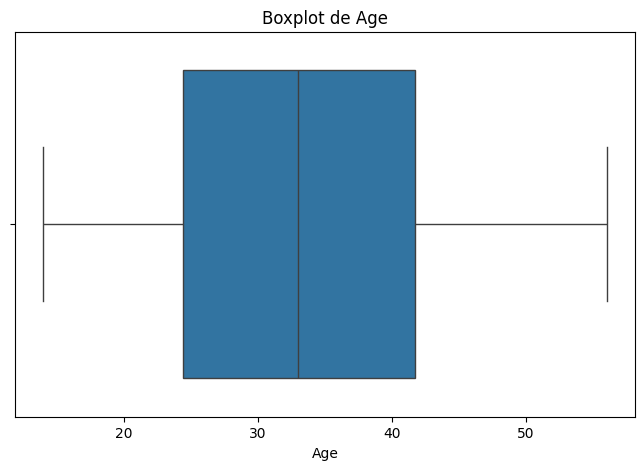

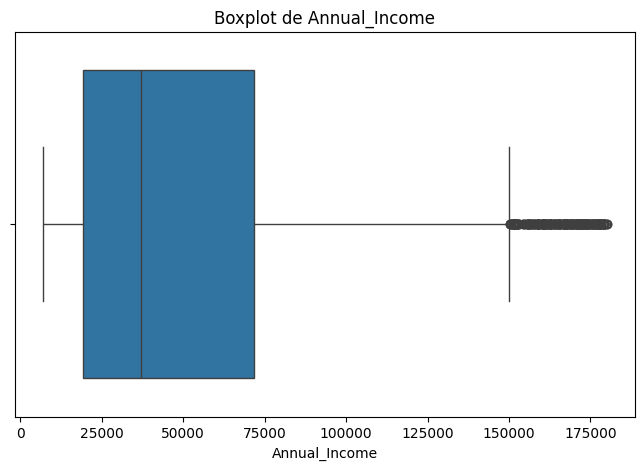

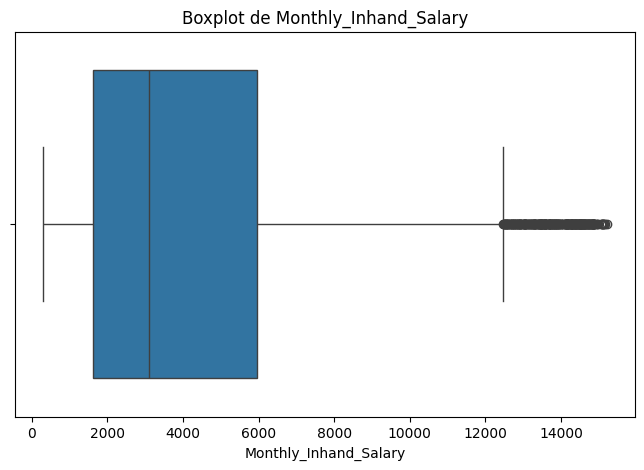

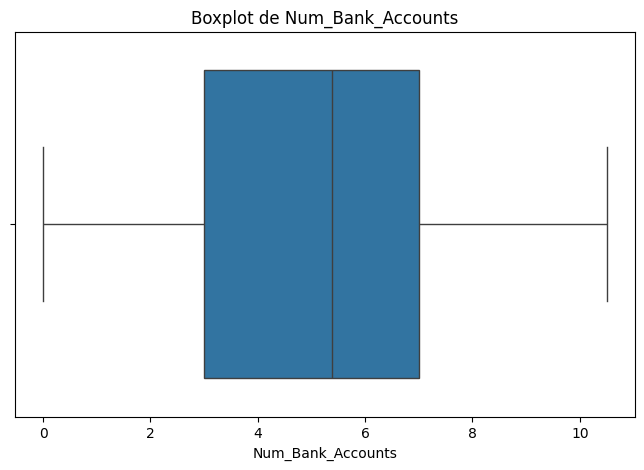

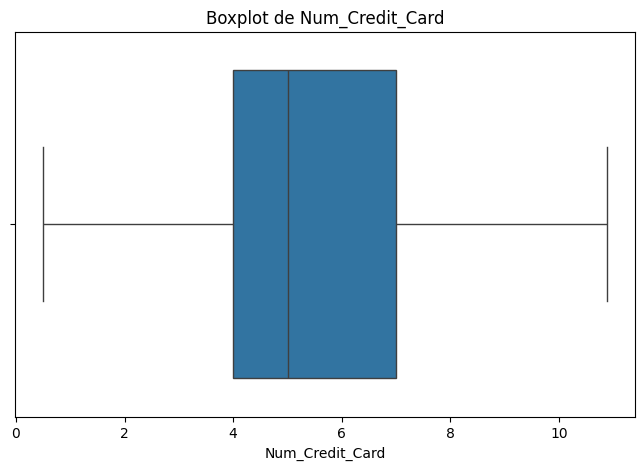

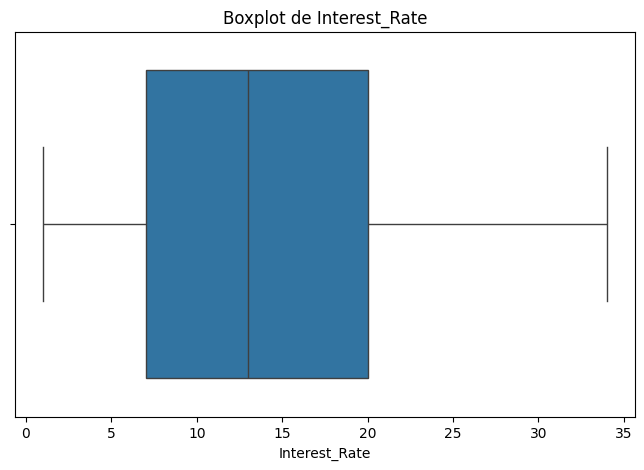

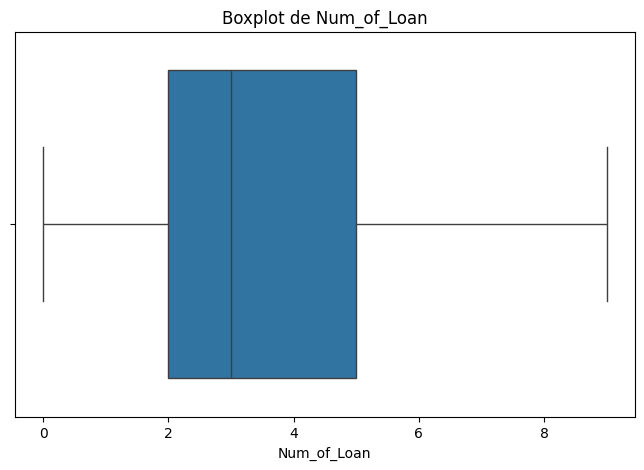

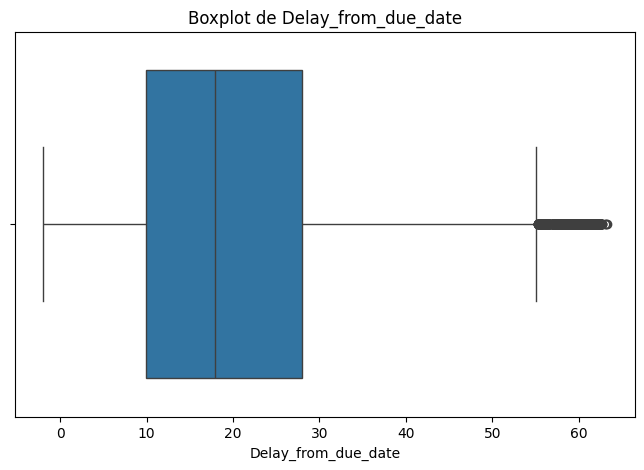

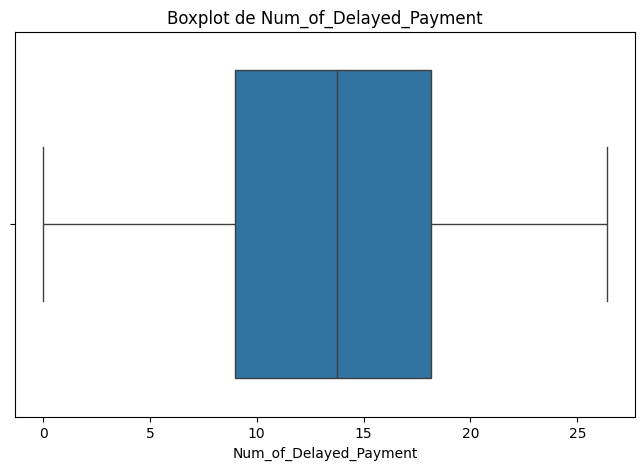

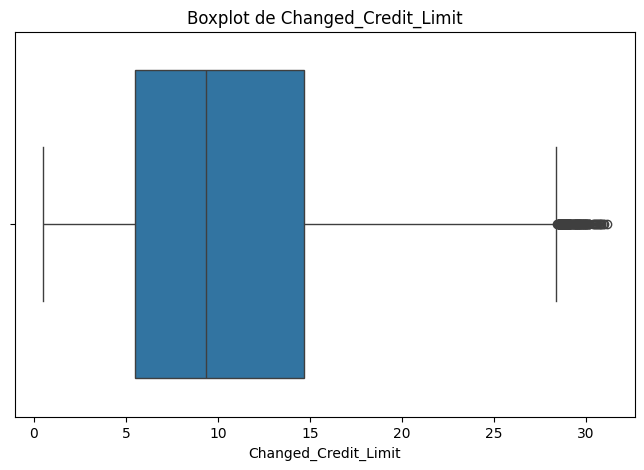

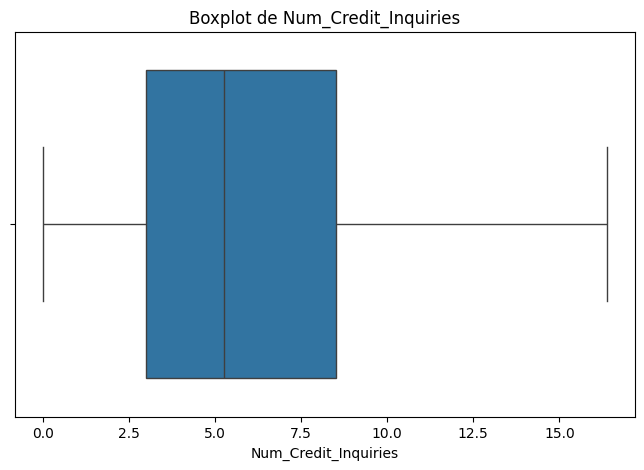

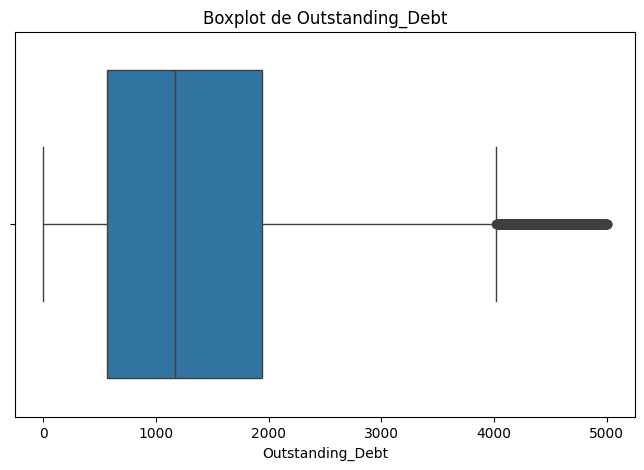

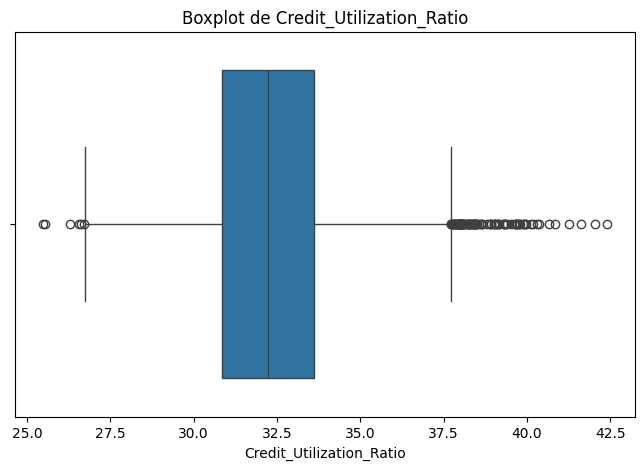

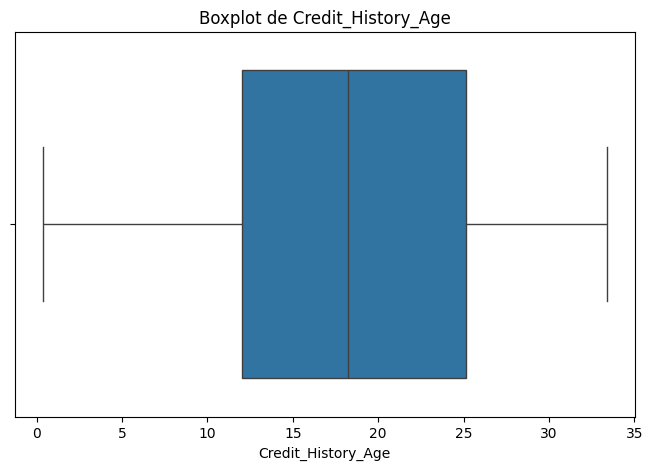

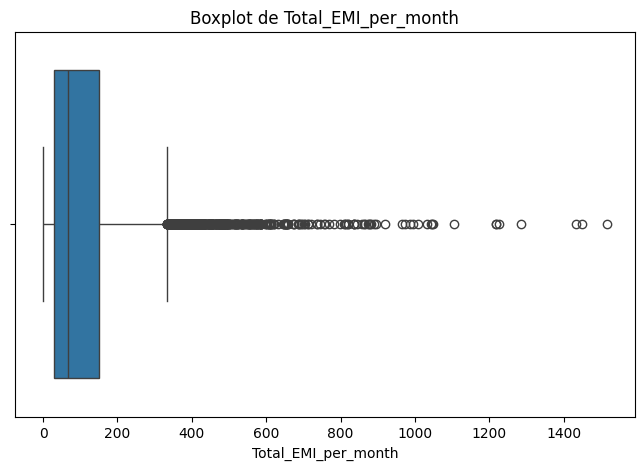

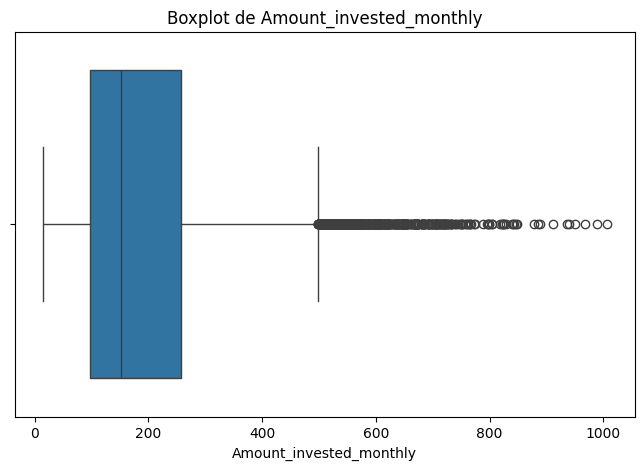

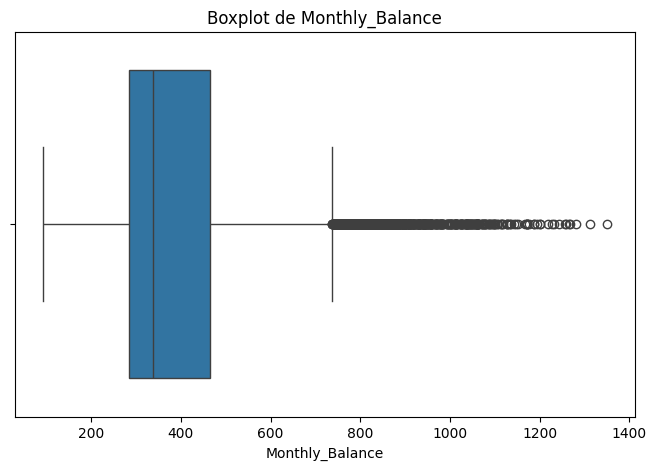

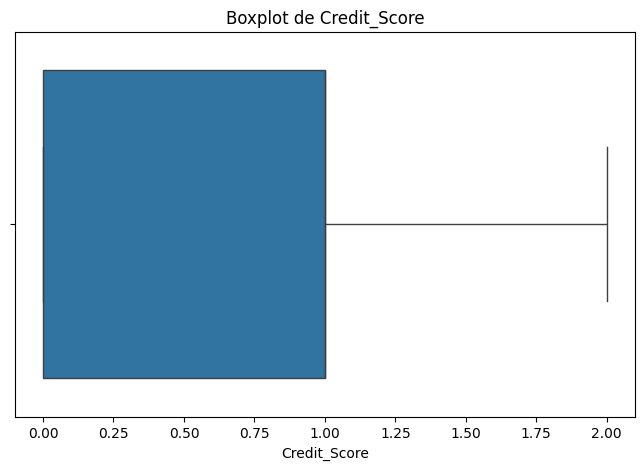

In [9]:
# Crea un boxplot para cada variable numérica para detectar posibles outliers
import matplotlib.pyplot as plt
import seaborn as sns
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.show()


Hay una considerable cantidad de datos atípicos en las variables numéricas, tal como es posible observar.

3. Preprocesamiento (preprocessing)

* En seguida, se procede a realizar el preprocesamiento: quitar los features inútiles, tratar los outliers, tratar los nulos, codificar los valores categóricos a numéricos y normalización de los datos para, posteriormente, "alimentar" la red neuronal con un conjunto de datos de buena calidad

In [10]:
# Drop de columnas que no aportan información relevante para el modelo
df.drop(['Customer_ID', 'Name', 'SSN'], axis=1, inplace=True)
df.head(4)

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,17.375,Lawyer,30625.94,2706.161667,6.0,5.0,27,2,"Credit-Builder Loan, and Home Equity Loan",62.25,25.000000,1.880000,10.875000,Bad,1562.91,33.477546,10.458333,Yes,42.941090,158.549735,High_spent_Medium_value_payments,335.375341,0
1,25.750,Mechanic,52312.68,4250.390000,6.0,5.0,17,4,"Not Specified, Home Equity Loan, Credit-Builde...",7.25,17.857143,9.730000,3.000000,Standard,202.68,29.839984,30.714286,Yes,108.366467,146.679378,High_spent_Medium_value_payments,428.743155,1
2,18.500,Media_Manager,113781.39,9549.782500,1.0,4.0,1,0,NaN,13.50,7.375000,10.911429,1.857143,Good,1030.20,34.841449,15.571429,No,0.000000,505.386526,High_spent_Large_value_payments,781.229776,0
3,43.875,Doctor,58918.47,5208.872500,3.0,3.0,17,3,"Student Loan, Credit-Builder Loan, and Debt Co...",27.25,14.500000,14.170000,7.000000,Standard,473.14,27.655897,15.541667,Yes,123.434939,311.060914,Low_spent_Medium_value_payments,332.642837,1


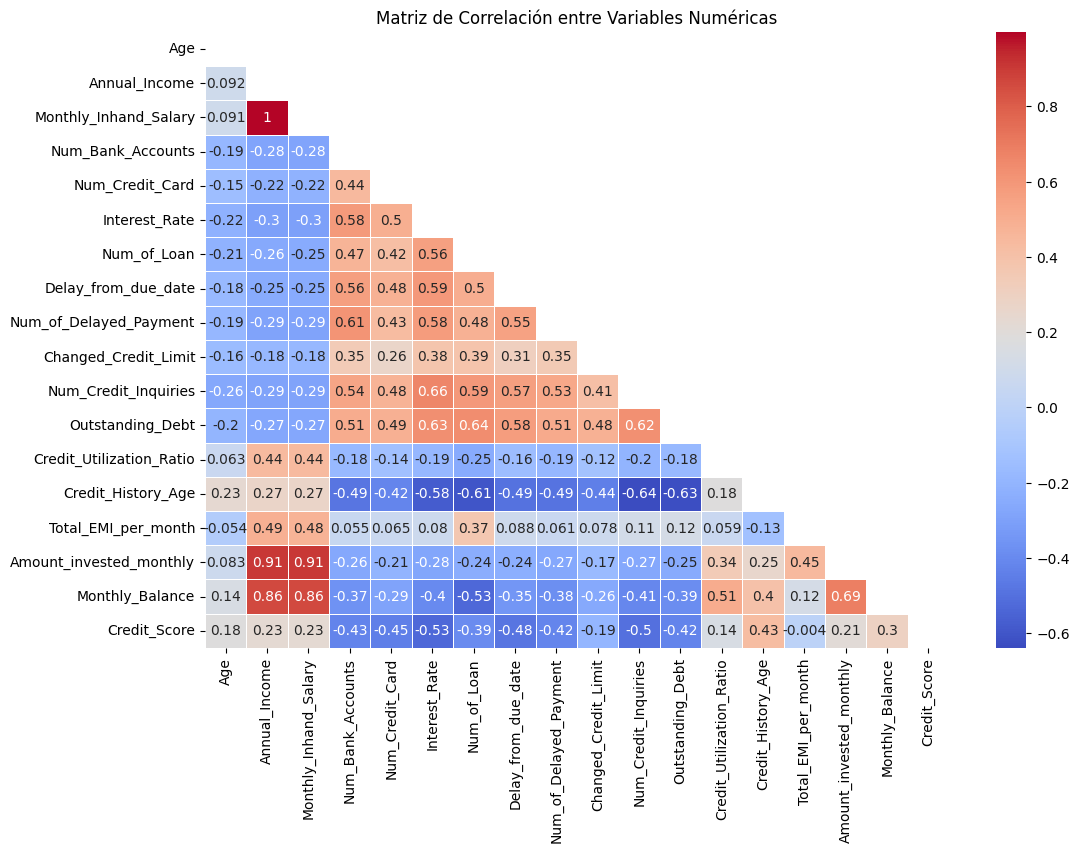

In [11]:
# Correlación entre variables numéricas, con una máscara de calor para visualizar mejor las relaciones
import numpy as np

correlation_matrix = df[numerical_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación entre Variables Numéricas')
plt.show()

* Ahora, se procederá a quitar una de las variables correlacionadas, dado que hay una correlacionada al 100% y otras, 91% y 86%.

In [12]:
# Drop de la variable 'Monthly_Inhand_Salary' porque tiene correlación del 100% con Annual_Income
df.drop(['Monthly_Inhand_Salary'], axis=1, inplace=True)

In [13]:
df

,Age,Occupation,Annual_Income,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,17.375000,Lawyer,30625.940,6.0,5.0,27,2,"Credit-Builder Loan, and Home Equity Loan",62.250,25.000000,1.880000,10.875000,Bad,1562.91,33.477546,10.458333,Yes,42.941090,158.549735,High_spent_Medium_value_payments,335.375341,0
1,25.750000,Mechanic,52312.680,6.0,5.0,17,4,"Not Specified, Home Equity Loan, Credit-Builde...",7.250,17.857143,9.730000,3.000000,Standard,202.68,29.839984,30.714286,Yes,108.366467,146.679378,High_spent_Medium_value_payments,428.743155,1
2,18.500000,Media_Manager,113781.390,1.0,4.0,1,0,NaN,13.500,7.375000,10.911429,1.857143,Good,1030.20,34.841449,15.571429,No,0.000000,505.386526,High_spent_Large_value_payments,781.229776,0
3,43.875000,Doctor,58918.470,3.0,3.0,17,3,"Student Loan, Credit-Builder Loan, and Debt Co...",27.250,14.500000,14.170000,7.000000,Standard,473.14,27.655897,15.541667,Yes,123.434939,311.060914,Low_spent_Medium_value_payments,332.642837,1
4,43.750000,Mechanic,98620.980,3.0,3.0,6,3,"Student Loan, Debt Consolidation Loan, and Per...",12.500,8.428571,1.705000,3.000000,Good,1233.51,31.933940,17.535714,No,228.018084,355.442408,High_spent_Medium_value_payments,472.781009,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12495,55.000000,Scientist,17032.785,0.0,6.0,2,3,"Personal Loan, Mortgage Loan, and Auto Loan",12.250,8.625000,8.485000,4.250000,Good,1229.08,32.889398,17.000000,No,33.299764,83.918549,Low_spent_Small_value_payments,271.671562,1
12496,36.857143,Entrepreneur,25546.260,8.0,7.0,14,5,"Not Specified, Student Loan, Student Loan, Cre...",15.875,12.125000,8.205000,5.000000,Standard,758.44,32.598257,18.440476,Yes,101.328637,152.775690,Low_spent_Small_value_payments,259.981173,1
12497,18.625000,Doctor,117639.920,5.0,6.0,1,2,"Home Equity Loan, and Auto Loan",-0.125,4.000000,11.900000,2.000000,Good,338.30,33.258053,24.625000,No,126.638453,655.228203,High_spent_Small_value_payments,667.322417,1
12498,17.375000,Musician,60877.170,6.0,8.0,27,8,"Credit-Builder Loan, Payday Loan, Not Specifie...",45.375,16.250000,8.820000,12.375000,Bad,1300.13,34.722108,12.861111,Yes,272.809169,156.172974,High_spent_Large_value_payments,339.951771,0


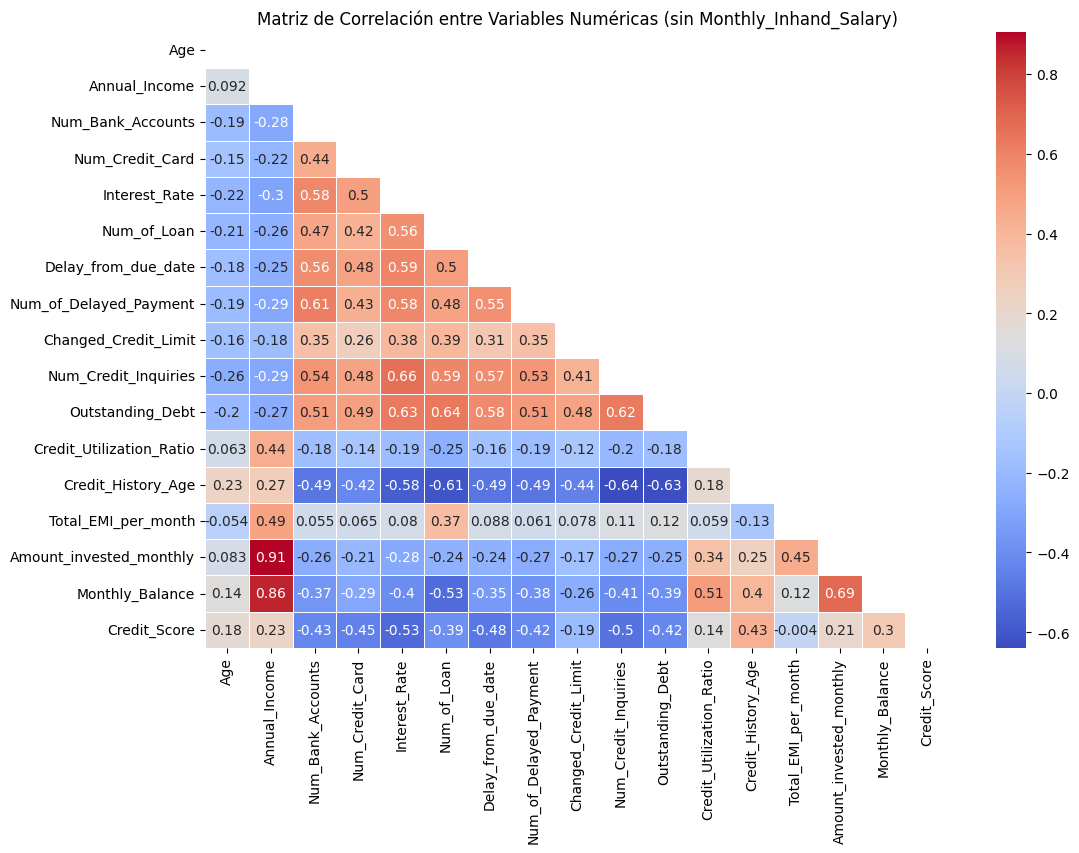

In [14]:
# Volver a verificar la correlación después de eliminar la variable Monthly_Inhand_Salary
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_cols].corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación entre Variables Numéricas (sin Monthly_Inhand_Salary)')
plt.show()

In [15]:
# Se dropea la variable Annual_Income dado que tiene correlaciones de 91% y 86% con las variables de Monthly_Balance y Amount_invested_monthly
df.drop(['Annual_Income'], axis=1, inplace=True)

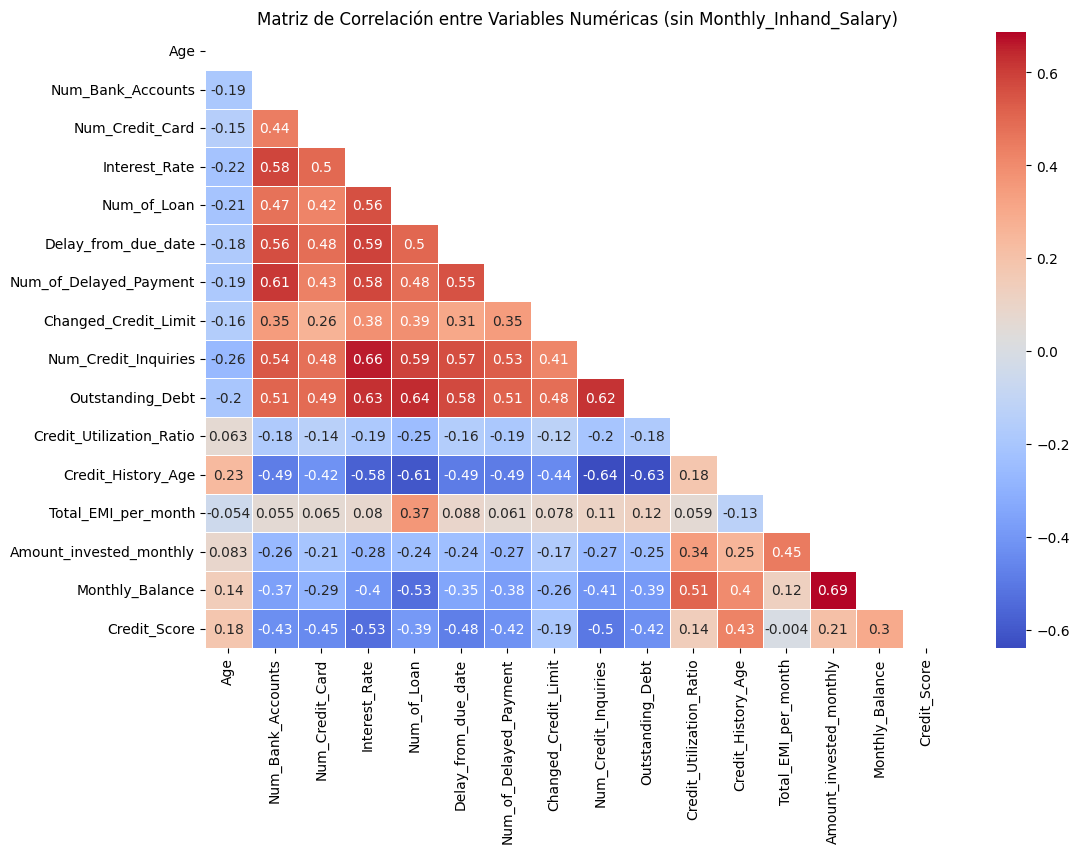

In [16]:
# Volver a verificar la correlación después de eliminar la variable Annual_Income
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_cols].corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación entre Variables Numéricas (sin Monthly_Inhand_Salary)')
plt.show()

* Ahora, es necesario observar qué características numéricas quedaron

In [17]:
# Ver las características numéricas después de eliminar las variables con alta correlación
df[numerical_cols].describe()

,Age,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score
count,12500.000000,12500.000000,12500.00000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000
mean,33.311294,5.368828,5.53362,14.532080,3.532880,21.068780,13.338642,10.465068,5.779694,1426.220376,32.285069,18.433820,107.698610,195.751837,403.120320,0.845200
std,10.760177,2.592493,2.06604,8.741636,2.446442,14.772965,6.153148,6.445141,3.707936,1155.169458,2.060154,8.304817,118.990964,136.847120,175.476887,0.697994
min,14.000000,0.000000,0.50000,1.000000,0.000000,-2.000000,0.000000,0.500000,0.000000,0.230000,25.476634,0.375000,0.000000,14.528879,92.841401,0.000000
25%,24.415179,3.000000,4.00000,7.000000,2.000000,9.875000,9.000000,5.493750,3.000000,566.072500,30.854492,12.041667,30.333649,97.690749,284.546710,0.000000
50%,33.000000,5.375000,5.00000,13.000000,3.000000,17.875000,13.750000,9.370000,5.250000,1166.155000,32.241830,18.238095,68.102176,152.081485,338.491580,1.000000
75%,41.750000,7.000000,7.00000,20.000000,5.000000,28.000000,18.175000,14.656250,8.500000,1945.962500,33.600168,25.125000,151.220882,257.566585,465.372970,1.000000
max,56.000000,10.500000,10.87500,34.000000,9.000000,63.250000,26.375000,31.115000,16.375000,4998.070000,42.395301,33.380952,1515.158986,1005.847285,1349.264887,2.000000


In [18]:
df[numerical_cols].isnull().sum()

,0
Age,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Delay_from_due_date,0
Num_of_Delayed_Payment,0
Changed_Credit_Limit,0
Num_Credit_Inquiries,0
Outstanding_Debt,0


In [19]:
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols].isnull().sum()

,0
Occupation,0
Type_of_Loan,1426
Credit_Mix,0
Payment_of_Min_Amount,0
Payment_Behaviour,0


In [20]:
df[categorical_cols] 

,Occupation,Type_of_Loan,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour
0,Lawyer,"Credit-Builder Loan, and Home Equity Loan",Bad,Yes,High_spent_Medium_value_payments
1,Mechanic,"Not Specified, Home Equity Loan, Credit-Builde...",Standard,Yes,High_spent_Medium_value_payments
2,Media_Manager,NaN,Good,No,High_spent_Large_value_payments
3,Doctor,"Student Loan, Credit-Builder Loan, and Debt Co...",Standard,Yes,Low_spent_Medium_value_payments
4,Mechanic,"Student Loan, Debt Consolidation Loan, and Per...",Good,No,High_spent_Medium_value_payments
...,...,...,...,...,...
12495,Scientist,"Personal Loan, Mortgage Loan, and Auto Loan",Good,No,Low_spent_Small_value_payments
12496,Entrepreneur,"Not Specified, Student Loan, Student Loan, Cre...",Standard,Yes,Low_spent_Small_value_payments
12497,Doctor,"Home Equity Loan, and Auto Loan",Good,No,High_spent_Small_value_payments
12498,Musician,"Credit-Builder Loan, Payday Loan, Not Specifie...",Bad,Yes,High_spent_Large_value_payments


In [21]:
for col in categorical_cols:
    print(f"Valores únicos en {col}: {df[col].value_counts()}")
    print("\n")

Valores únicos en Occupation: Occupation
Lawyer           887
Engineer         858
Architect        853
Mechanic         847
Scientist        843
Accountant       843
Media_Manager    840
Developer        840
Teacher          834
Entrepreneur     831
Doctor           821
Journalist       817
Manager          804
Musician         794
Writer           788
Name: count, dtype: int64


Valores únicos en Type_of_Loan: Type_of_Loan
Not Specified                                                                                 176
Credit-Builder Loan                                                                           160
Personal Loan                                                                                 159
Debt Consolidation Loan                                                                       158
Student Loan                                                                                  155
                                                                                 

* Es necesario, por tanto, realizar la debida codificación a las variables categóricas, mediante one-hot encoding, mapeo ordinal, label encoding y extracción de información (para Type_of_Loan)

In [22]:
# One-Hot Encoding para Occupation
df = pd.get_dummies(df, columns=['Occupation'], drop_first=True)
df = df.astype({col: int for col in df.select_dtypes('bool').columns})
df.head()

,Age,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Occupation_Architect,Occupation_Developer,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer
0,17.375,6.0,5.0,27,2,"Credit-Builder Loan, and Home Equity Loan",62.25,25.000000,1.880000,10.875000,Bad,1562.91,33.477546,10.458333,Yes,42.941090,158.549735,High_spent_Medium_value_payments,335.375341,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,25.750,6.0,5.0,17,4,"Not Specified, Home Equity Loan, Credit-Builde...",7.25,17.857143,9.730000,3.000000,Standard,202.68,29.839984,30.714286,Yes,108.366467,146.679378,High_spent_Medium_value_payments,428.743155,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,18.500,1.0,4.0,1,0,NaN,13.50,7.375000,10.911429,1.857143,Good,1030.20,34.841449,15.571429,No,0.000000,505.386526,High_spent_Large_value_payments,781.229776,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,43.875,3.0,3.0,17,3,"Student Loan, Credit-Builder Loan, and Debt Co...",27.25,14.500000,14.170000,7.000000,Standard,473.14,27.655897,15.541667,Yes,123.434939,311.060914,Low_spent_Medium_value_payments,332.642837,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
4,43.750,3.0,3.0,6,3,"Student Loan, Debt Consolidation Loan, and Per...",12.50,8.428571,1.705000,3.000000,Good,1233.51,31.933940,17.535714,No,228.018084,355.442408,High_spent_Medium_value_payments,472.781009,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [23]:
# Crear una variable Num_of_Loans_Total que cuente cuantos préstamos aparecen en el texto, separado por comas, de la variable Type_of_Loan
def count_loans(loan_str):
    if pd.isnull(loan_str):
        return 0
    return len(loan_str.split(','))
df['Num_of_Loans_Total'] = df['Type_of_Loan'].apply(count_loans)
df.head()

,Age,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Occupation_Architect,Occupation_Developer,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer,Num_of_Loans_Total
0,17.375,6.0,5.0,27,2,"Credit-Builder Loan, and Home Equity Loan",62.25,25.000000,1.880000,10.875000,Bad,1562.91,33.477546,10.458333,Yes,42.941090,158.549735,High_spent_Medium_value_payments,335.375341,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,2
1,25.750,6.0,5.0,17,4,"Not Specified, Home Equity Loan, Credit-Builde...",7.25,17.857143,9.730000,3.000000,Standard,202.68,29.839984,30.714286,Yes,108.366467,146.679378,High_spent_Medium_value_payments,428.743155,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,4
2,18.500,1.0,4.0,1,0,NaN,13.50,7.375000,10.911429,1.857143,Good,1030.20,34.841449,15.571429,No,0.000000,505.386526,High_spent_Large_value_payments,781.229776,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,43.875,3.0,3.0,17,3,"Student Loan, Credit-Builder Loan, and Debt Co...",27.25,14.500000,14.170000,7.000000,Standard,473.14,27.655897,15.541667,Yes,123.434939,311.060914,Low_spent_Medium_value_payments,332.642837,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3
4,43.750,3.0,3.0,6,3,"Student Loan, Debt Consolidation Loan, and Per...",12.50,8.428571,1.705000,3.000000,Good,1233.51,31.933940,17.535714,No,228.018084,355.442408,High_spent_Medium_value_payments,472.781009,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,3


In [24]:
# Mapeo ordinal de Credit_Mix
mapping = {'Bad': 0, 'Standard': 1, 'Good': 2}
df['Credit_Mix'] = df['Credit_Mix'].map(mapping)
df.head()

,Age,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Occupation_Architect,Occupation_Developer,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer,Num_of_Loans_Total
0,17.375,6.0,5.0,27,2,"Credit-Builder Loan, and Home Equity Loan",62.25,25.000000,1.880000,10.875000,0,1562.91,33.477546,10.458333,Yes,42.941090,158.549735,High_spent_Medium_value_payments,335.375341,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,2
1,25.750,6.0,5.0,17,4,"Not Specified, Home Equity Loan, Credit-Builde...",7.25,17.857143,9.730000,3.000000,1,202.68,29.839984,30.714286,Yes,108.366467,146.679378,High_spent_Medium_value_payments,428.743155,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,4
2,18.500,1.0,4.0,1,0,NaN,13.50,7.375000,10.911429,1.857143,2,1030.20,34.841449,15.571429,No,0.000000,505.386526,High_spent_Large_value_payments,781.229776,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,43.875,3.0,3.0,17,3,"Student Loan, Credit-Builder Loan, and Debt Co...",27.25,14.500000,14.170000,7.000000,1,473.14,27.655897,15.541667,Yes,123.434939,311.060914,Low_spent_Medium_value_payments,332.642837,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3
4,43.750,3.0,3.0,6,3,"Student Loan, Debt Consolidation Loan, and Per...",12.50,8.428571,1.705000,3.000000,2,1233.51,31.933940,17.535714,No,228.018084,355.442408,High_spent_Medium_value_payments,472.781009,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,3


In [25]:
# Tratar NM como nulo en Payment_of_Min_Amount e imputar con la moda, mapear Yes a 1 y No a 0
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', np.nan)
mode_payment = df['Payment_of_Min_Amount'].mode()[0]
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].fillna(mode_payment)
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].map({'Yes': 1, 'No': 0})
df.head()

,Age,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Occupation_Architect,Occupation_Developer,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer,Num_of_Loans_Total
0,17.375,6.0,5.0,27,2,"Credit-Builder Loan, and Home Equity Loan",62.25,25.000000,1.880000,10.875000,0,1562.91,33.477546,10.458333,1,42.941090,158.549735,High_spent_Medium_value_payments,335.375341,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,2
1,25.750,6.0,5.0,17,4,"Not Specified, Home Equity Loan, Credit-Builde...",7.25,17.857143,9.730000,3.000000,1,202.68,29.839984,30.714286,1,108.366467,146.679378,High_spent_Medium_value_payments,428.743155,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,4
2,18.500,1.0,4.0,1,0,NaN,13.50,7.375000,10.911429,1.857143,2,1030.20,34.841449,15.571429,0,0.000000,505.386526,High_spent_Large_value_payments,781.229776,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,43.875,3.0,3.0,17,3,"Student Loan, Credit-Builder Loan, and Debt Co...",27.25,14.500000,14.170000,7.000000,1,473.14,27.655897,15.541667,1,123.434939,311.060914,Low_spent_Medium_value_payments,332.642837,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3
4,43.750,3.0,3.0,6,3,"Student Loan, Debt Consolidation Loan, and Per...",12.50,8.428571,1.705000,3.000000,2,1233.51,31.933940,17.535714,0,228.018084,355.442408,High_spent_Medium_value_payments,472.781009,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,3


In [26]:
# Ordinal Encoding a Payment_Behaviour de 0 a 5  
mapping_payment_behaviour = {
    'Low_spent_Small_value_payments': 0,
    'High_spent_Medium_value_payments': 1,
    'High_spent_Large_value_payments': 2,
    'Low_spent_Medium_value_payments': 3,
    'High_spent_Small_value_payments': 4,
    'Low_spent_Large_value_payments': 5
}
df['Payment_Behaviour'] = df['Payment_Behaviour'].map(mapping_payment_behaviour)
df.head()

,Age,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Occupation_Architect,Occupation_Developer,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer,Num_of_Loans_Total
0,17.375,6.0,5.0,27,2,"Credit-Builder Loan, and Home Equity Loan",62.25,25.000000,1.880000,10.875000,0,1562.91,33.477546,10.458333,1,42.941090,158.549735,1,335.375341,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,2
1,25.750,6.0,5.0,17,4,"Not Specified, Home Equity Loan, Credit-Builde...",7.25,17.857143,9.730000,3.000000,1,202.68,29.839984,30.714286,1,108.366467,146.679378,1,428.743155,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,4
2,18.500,1.0,4.0,1,0,NaN,13.50,7.375000,10.911429,1.857143,2,1030.20,34.841449,15.571429,0,0.000000,505.386526,2,781.229776,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,43.875,3.0,3.0,17,3,"Student Loan, Credit-Builder Loan, and Debt Co...",27.25,14.500000,14.170000,7.000000,1,473.14,27.655897,15.541667,1,123.434939,311.060914,3,332.642837,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3
4,43.750,3.0,3.0,6,3,"Student Loan, Debt Consolidation Loan, and Per...",12.50,8.428571,1.705000,3.000000,2,1233.51,31.933940,17.535714,0,228.018084,355.442408,1,472.781009,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,3


In [27]:
# Verificar los tipos de datos después de las transformaciones
df.dtypes

,0
Age,float64
Num_Bank_Accounts,float64
Num_Credit_Card,float64
Interest_Rate,int64
Num_of_Loan,int64
Type_of_Loan,object
Delay_from_due_date,float64
Num_of_Delayed_Payment,float64
Changed_Credit_Limit,float64
Num_Credit_Inquiries,float64


In [28]:
df.drop(['Type_of_Loan'], axis=1, inplace=True)
df.head()

,Age,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Occupation_Architect,Occupation_Developer,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer,Num_of_Loans_Total
0,17.375,6.0,5.0,27,2,62.25,25.000000,1.880000,10.875000,0,1562.91,33.477546,10.458333,1,42.941090,158.549735,1,335.375341,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,2
1,25.750,6.0,5.0,17,4,7.25,17.857143,9.730000,3.000000,1,202.68,29.839984,30.714286,1,108.366467,146.679378,1,428.743155,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,4
2,18.500,1.0,4.0,1,0,13.50,7.375000,10.911429,1.857143,2,1030.20,34.841449,15.571429,0,0.000000,505.386526,2,781.229776,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,43.875,3.0,3.0,17,3,27.25,14.500000,14.170000,7.000000,1,473.14,27.655897,15.541667,1,123.434939,311.060914,3,332.642837,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3
4,43.750,3.0,3.0,6,3,12.50,8.428571,1.705000,3.000000,2,1233.51,31.933940,17.535714,0,228.018084,355.442408,1,472.781009,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,3


In [29]:
df.dtypes

,0
Age,float64
Num_Bank_Accounts,float64
Num_Credit_Card,float64
Interest_Rate,int64
Num_of_Loan,int64
Delay_from_due_date,float64
Num_of_Delayed_Payment,float64
Changed_Credit_Limit,float64
Num_Credit_Inquiries,float64
Credit_Mix,int64


* Como es posible observar, todas los features son distintos al tipo object (solo numéricos). Ahora, se procederá a tratar los nulos.

In [30]:
df.isna().sum()

,0
Age,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Delay_from_due_date,0
Num_of_Delayed_Payment,0
Changed_Credit_Limit,0
Num_Credit_Inquiries,0
Credit_Mix,0


In [31]:
df.columns.to_list()

['Age',
 'Num_Bank_Accounts',
 'Num_Credit_Card',
 'Interest_Rate',
 'Num_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Num_Credit_Inquiries',
 'Credit_Mix',
 'Outstanding_Debt',
 'Credit_Utilization_Ratio',
 'Credit_History_Age',
 'Payment_of_Min_Amount',
 'Total_EMI_per_month',
 'Amount_invested_monthly',
 'Payment_Behaviour',
 'Monthly_Balance',
 'Credit_Score',
 'Occupation_Architect',
 'Occupation_Developer',
 'Occupation_Doctor',
 'Occupation_Engineer',
 'Occupation_Entrepreneur',
 'Occupation_Journalist',
 'Occupation_Lawyer',
 'Occupation_Manager',
 'Occupation_Mechanic',
 'Occupation_Media_Manager',
 'Occupation_Musician',
 'Occupation_Scientist',
 'Occupation_Teacher',
 'Occupation_Writer',
 'Num_of_Loans_Total']

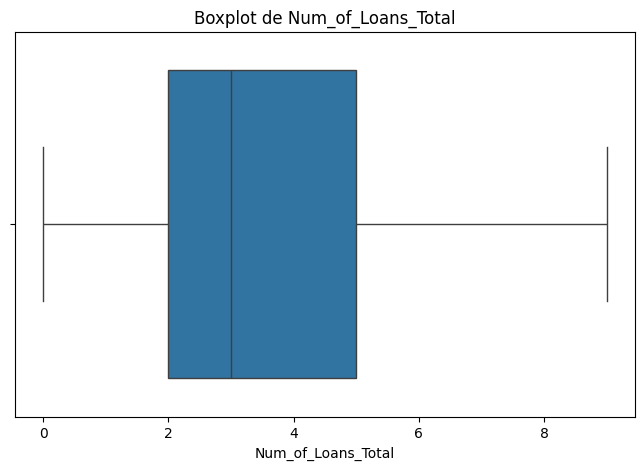

In [32]:
#Ver boxplot de Num_of_Loans_Total para detectar posibles outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Num_of_Loans_Total'])
plt.title('Boxplot de Num_of_Loans_Total')
plt.show()

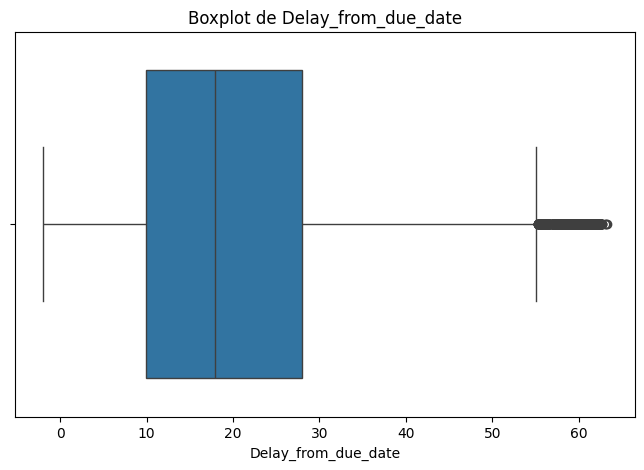

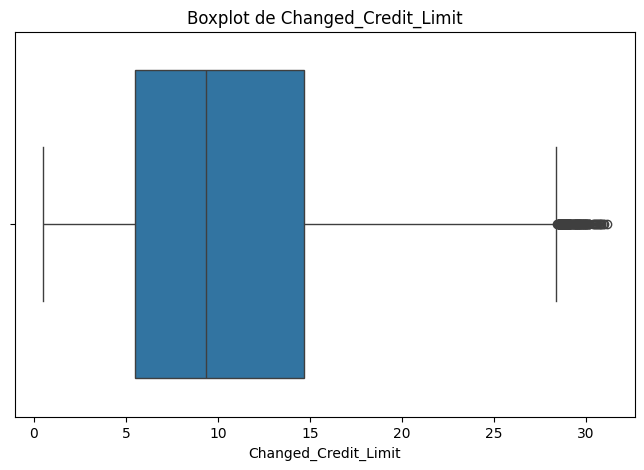

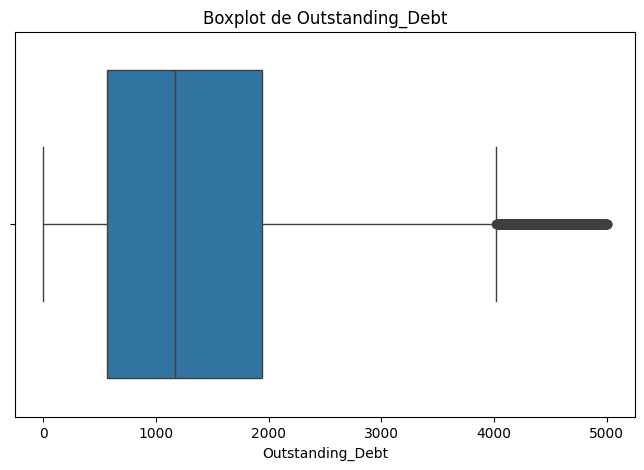

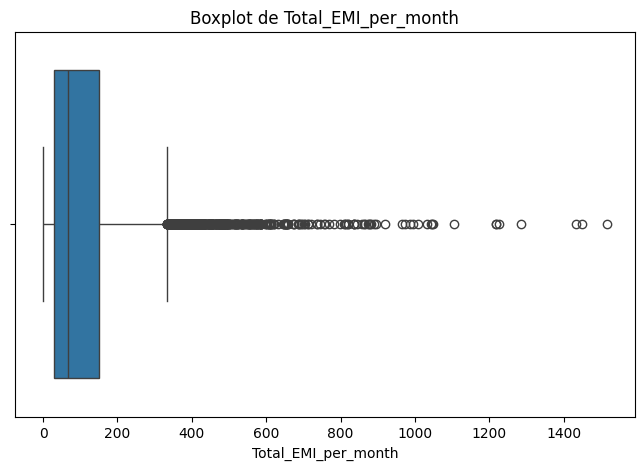

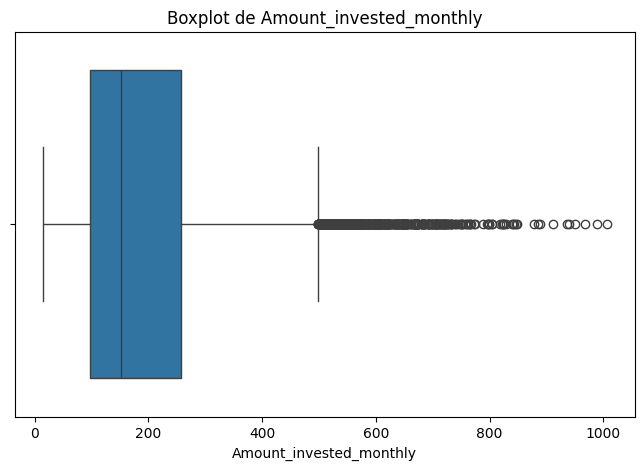

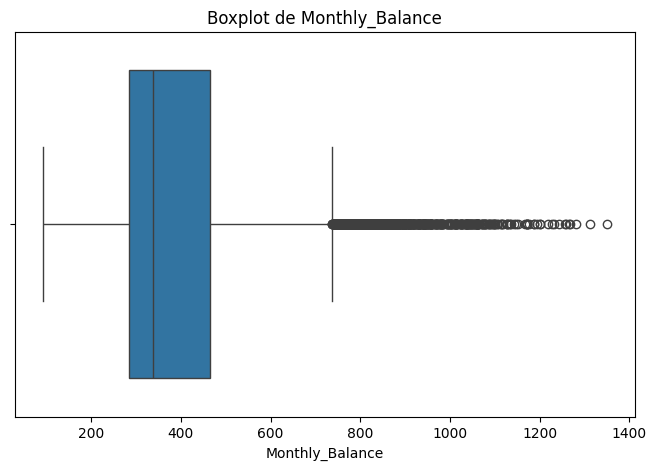

In [33]:
# Haz el boxplot de Delay_from_due_date, Changed_Credit_Limit, Outstanding_Debt, Total_EMI_per_month, Amount_invested_monthly, Monthly_Balance
cols_con_outliers = ['Delay_from_due_date', 'Changed_Credit_Limit', 'Outstanding_Debt', 
                    'Total_EMI_per_month', 'Amount_invested_monthly', 
                    'Monthly_Balance']
for col in cols_con_outliers:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

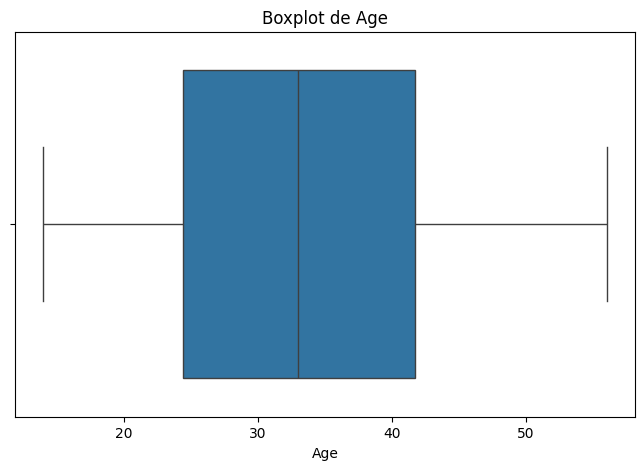

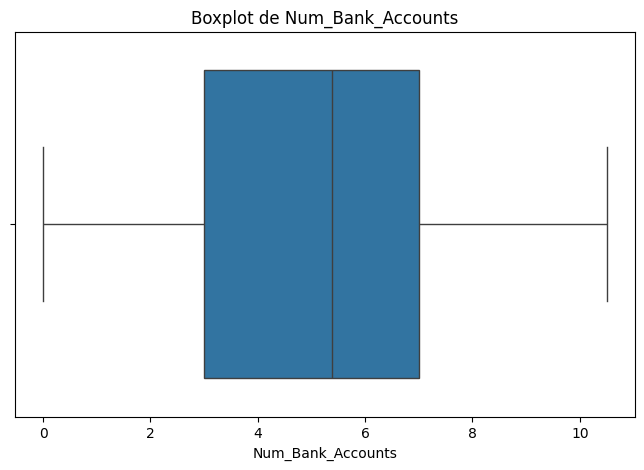

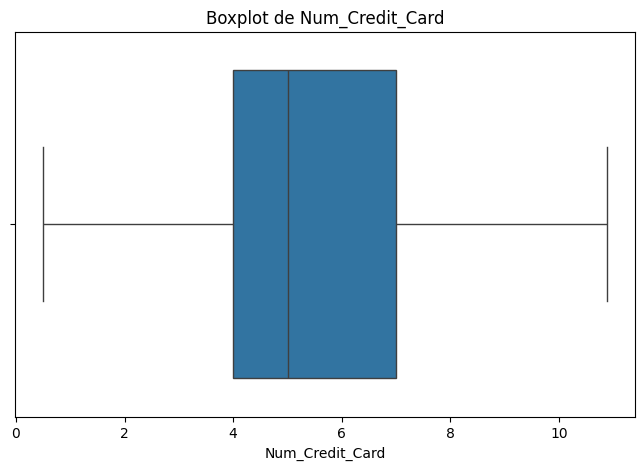

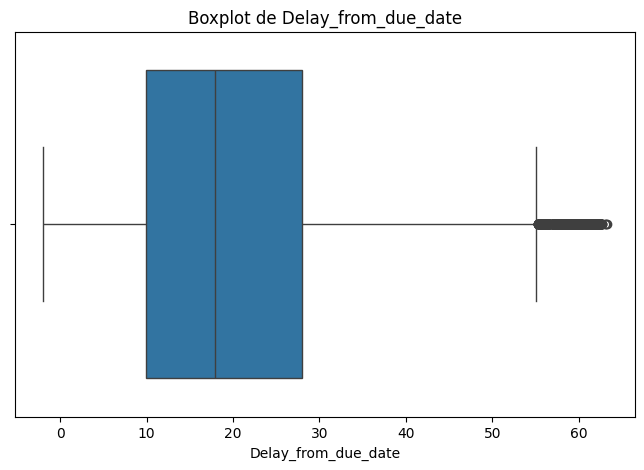

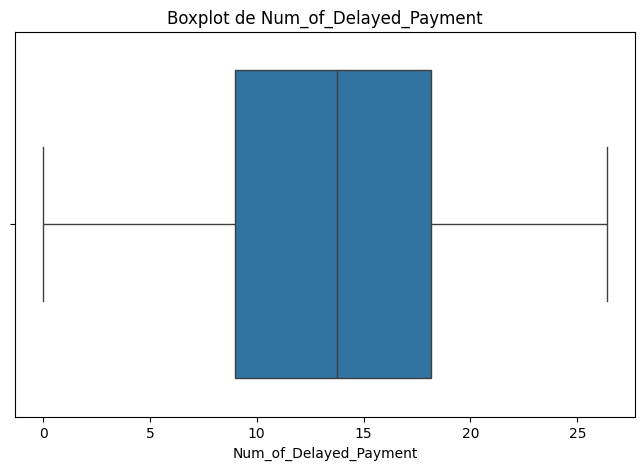

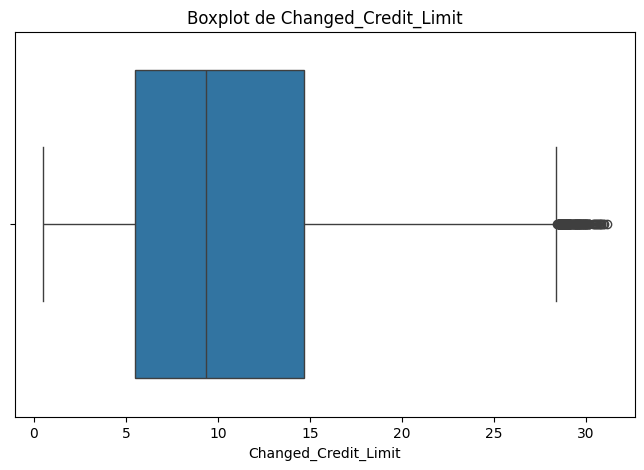

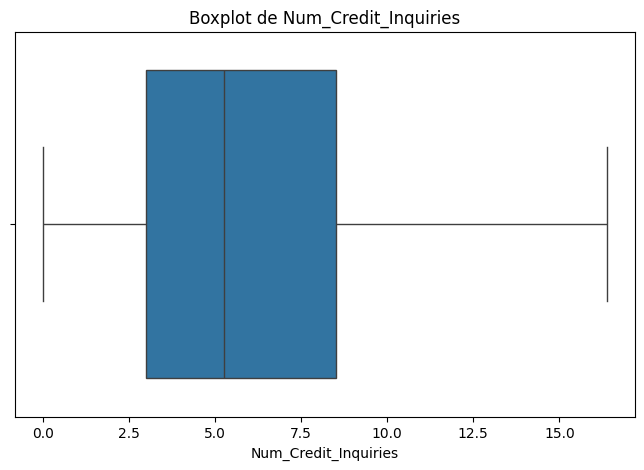

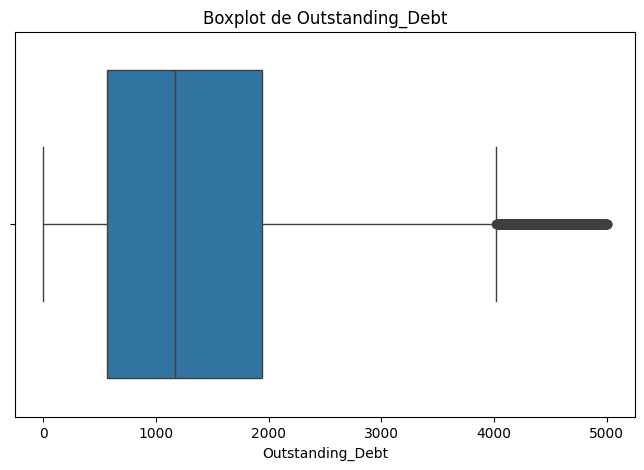

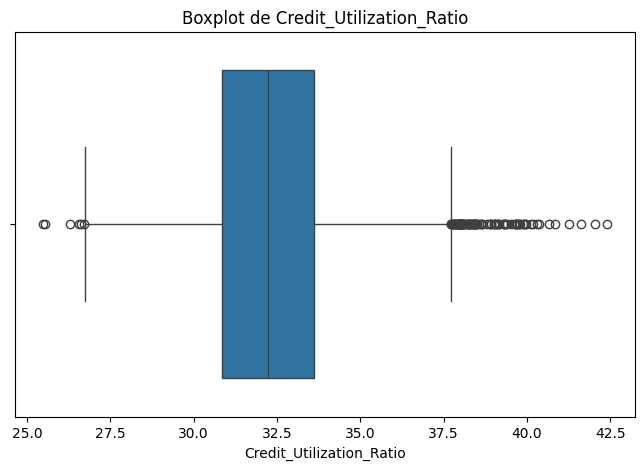

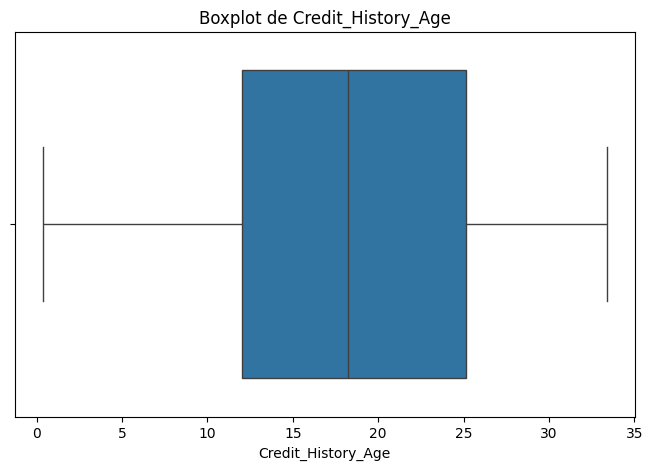

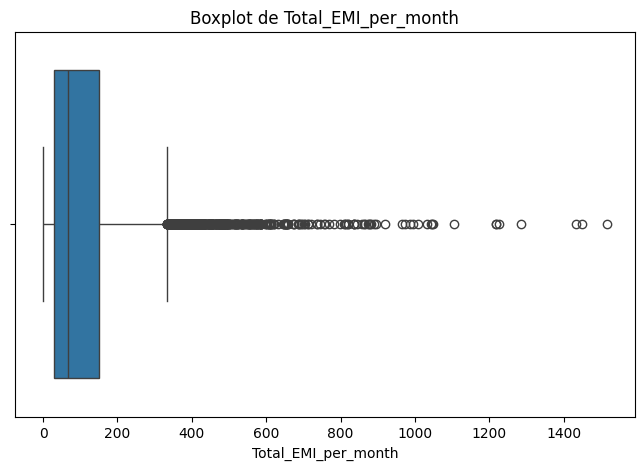

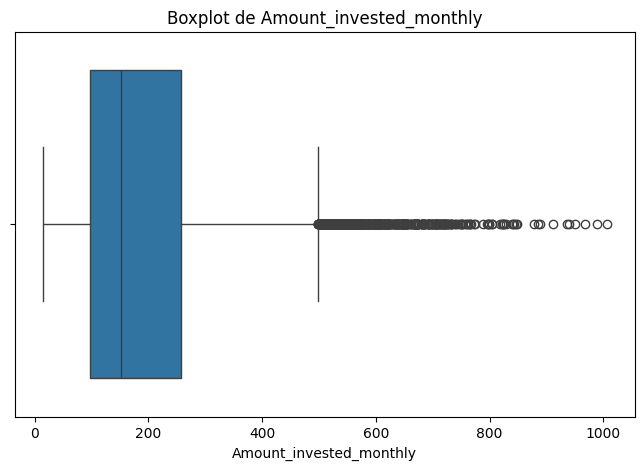

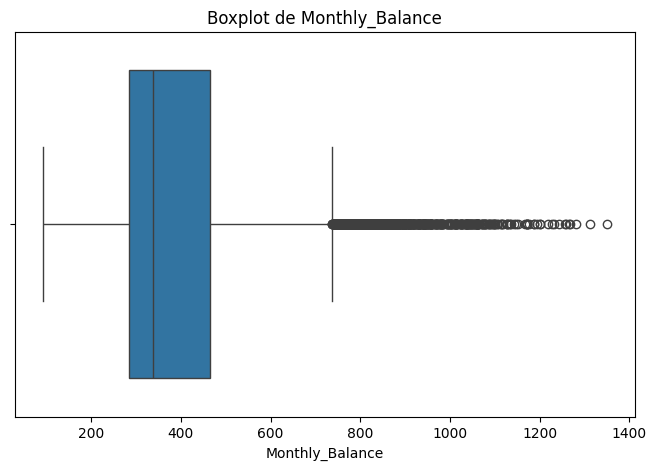

In [34]:
# Hacer boxplot de las columnas float64 para detectar posibles outliers
cols_float = df.select_dtypes(include=['float64']).columns
for col in cols_float:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

In [35]:
cols_con_outliers = ['Delay_from_due_date', 'Changed_Credit_Limit', 'Outstanding_Debt', 
                    'Total_EMI_per_month', 'Amount_invested_monthly', 
                    'Monthly_Balance', 'Credit_Utilization_Ratio']

for col in cols_con_outliers:
    upper = df[col].quantile(0.99)
    lower = df[col].quantile(0.01)
    df[col] = df[col].clip(lower=lower, upper=upper)

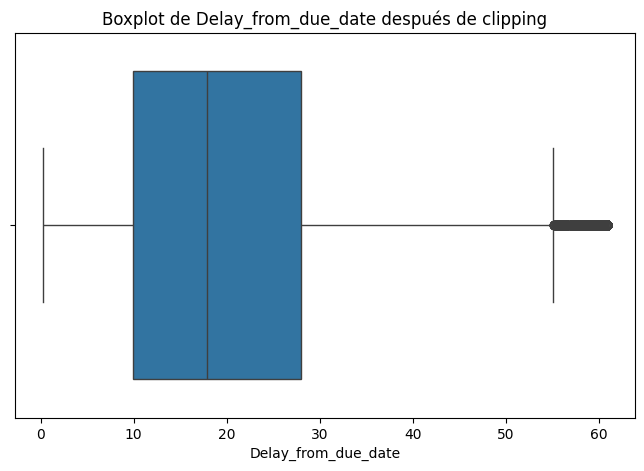

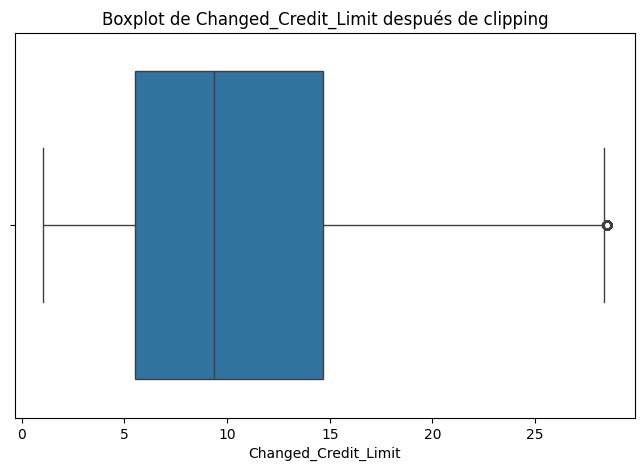

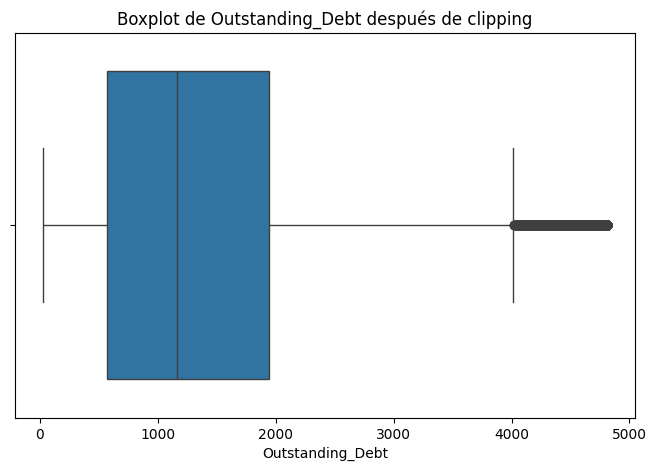

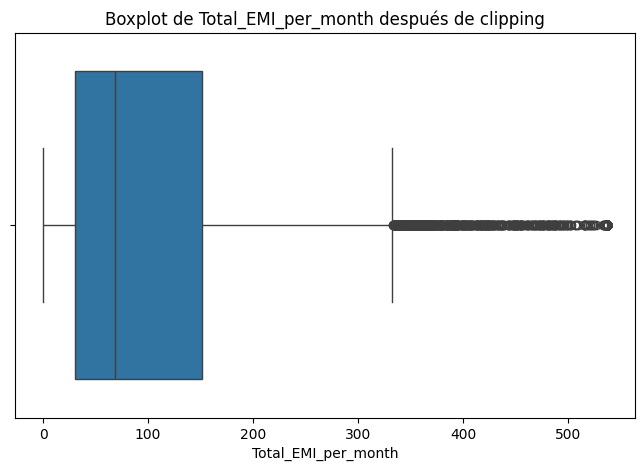

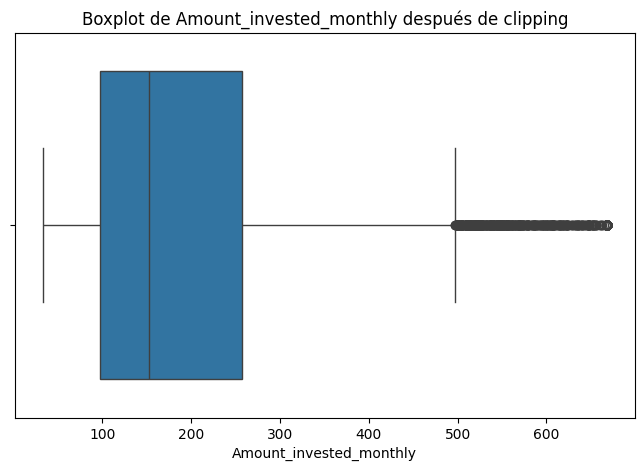

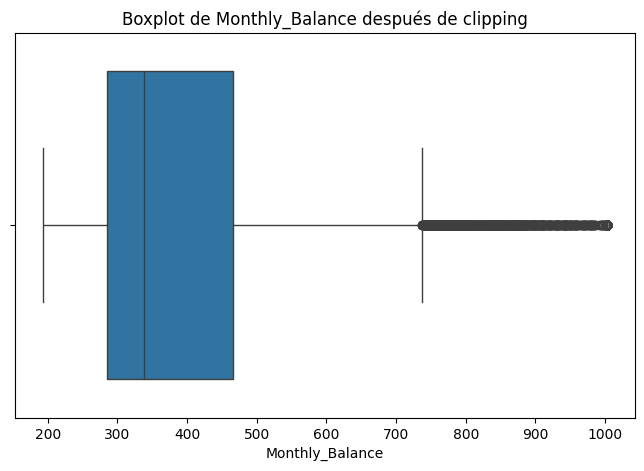

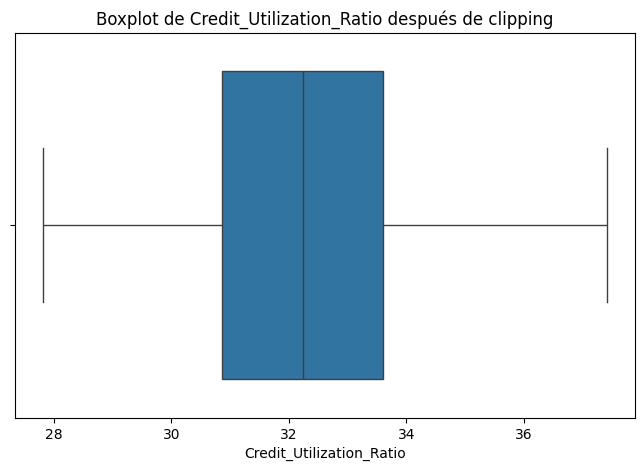

In [36]:
# Verificar los boxplots después de aplicar el clipping para ver si se han reducido los outliers
for col in cols_con_outliers:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col} después de clipping')
    plt.show()

In [37]:
# Verificar balanceo de la variable objetivo Credit_Score
df['Credit_Score'].value_counts(normalize=True) * 100

,proportion
Credit_Score,
1,48.888
0,33.296
2,17.816


**Separación de los datos en prueba, entrenamiento y validación**
* Ahora, se procede a separar los datos en estos tres conjuntos, asegurando que se entrenen con unos, se prueben con otros al finalizar el entrenamiento, y se valide mientras se entrena con otro conjunto.

In [38]:
from sklearn.model_selection import train_test_split

# 'X' contiene todas las variables MENOS la objetivo 'Credit_Score'
X = df.drop('Credit_Score', axis=1)

# 'y' contiene SOLO la columna que queremos predecir
y = df['Credit_Score']

#  Separar el 20% para el TEST final
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Del 80% restante, separar un 20% para VALIDACIÓN (aprox. 16% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

**Ahora, se escalarán los datos mediante StandardScaler, para que todos se encuentren en la misma escala y no influya la diferencia de escala.**

In [39]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

# Ajustar y transformar TRAIN
X_train_scaled = scaler.fit_transform(X_train)

# Solo transformar VAL y TEST
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [40]:
# Aplicar SMOTE SOLO al conjunto de entrenamiento escalado
from imblearn.over_sampling import SMOTE
import pandas as pd

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Verificación de balanceo
print("Distribución de clases después de SMOTE:")
print(pd.Series(y_train_res).value_counts())

Distribución de clases después de SMOTE:
Credit_Score
0    3911
1    3911
2    3911
Name: count, dtype: int64


* Se realiza, antes de ensamblar la red neuronal, una reducción de características para reducir la dimensionalidad del dataset

In [41]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.99)
X_train_pca = pca.fit_transform(X_train_scaled) # <--- Cambiado de X_train_scaled a X_train_res

# 3. Transformar VAL y TEST (Se quedan con su tamaño original, es correcto)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Componentes tras PCA: {pca.n_components_}")
print(f"Filas en X: {X_train_pca.shape[0]}")
print(f"Filas en y: {y_train_res.shape[0]}")

Componentes tras PCA: 30
Filas en X: 8000
Filas en y: 11733


4. Ensamblaje de red neuronal

* Dado que ya los datos de entrenamiento, validación y prueba fueron separados, y los datos fueron puestos en la misma escala, es posible (ahora) definir la arquitectura de la red neuronal densa mediante keras; esto incluye tanto "armarla" como compilarla con la función de pérdida, la métrica de validación, etc.

* Para esto, se usan keras y tensorflow

* Ahora, se compila el modelo definiendo un optimizador (adam), una función de pérdida (sparse_categorical_cross_entropy) y la métrica de validación (accuracy; ideal para clasificación)

5. Entrenamiento de red neuronal

**En este importante paso, se procederá a entrenar el modelo, validado por el conjunto de validación. Se usará early stopping**

In [42]:
#Definición de Early Stopping 
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, min_delta=0.01)

In [43]:
from tensorflow.keras import models, layers, optimizers
import keras

# 1. Definimos las arquitecturas
configuraciones = {
    "80_Plus": [64, 32, 16, 8],
    "Robusta": [64, 64, 32],
    "Wide_Deep": [128, 64, 32]
}

resultados = {}
mejor_val_acc = 0
mejor_modelo_final = None # Variable para guardar el objeto ganador

for nombre, capas in configuraciones.items():
    print(f"\nProbando arquitectura: {nombre}")
    
    # Construcción dinámica
    model_temp = models.Sequential()
    model_temp.add(layers.Input(shape=(X_train_pca.shape[1],)))
    for neuronas in capas:
        model_temp.add(layers.Dense(neuronas, activation='relu'))
    
    model_temp.add(layers.Dense(3, activation='softmax'))

    model_temp.compile(
        optimizer=optimizers.Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Entrenamiento con Early Stopping
    history = model_temp.fit(
        X_train_pca, y_train,
        epochs=500,
        validation_data=(X_val_pca, y_val),
        callbacks=[early_stopping],
    )
    
    val_acc = max(history.history['val_accuracy'])
    resultados[nombre] = val_acc
    print(f"Mejor val_accuracy para {nombre}: {val_acc:.4f}")

    # LÓGICA PARA GUARDAR EL MEJOR MODELO
    if val_acc >= mejor_val_acc:
        mejor_val_acc = val_acc
        mejor_modelo_final = model_temp # Aquí se guarda el OBJETO del modelo

# 2. Resumen de resultados
print("\n--- RESULTADOS FINALES ---")
for nombre, acc in resultados.items():
    print(f"{nombre}: {acc:.4f}")

print(f"\n🏆 El mejor modelo es {max(resultados, key=resultados.get)}")



Probando arquitectura: 80_Plus
Epoch 1/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3611 - loss: 1.0963 - val_accuracy: 0.4880 - val_loss: 1.0310
Epoch 2/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5105 - loss: 1.0135 - val_accuracy: 0.5740 - val_loss: 0.9851
Epoch 3/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5959 - loss: 0.9640 - val_accuracy: 0.6255 - val_loss: 0.9147
Epoch 4/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6409 - loss: 0.8837 - val_accuracy: 0.6540 - val_loss: 0.8250
Epoch 5/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6719 - loss: 0.7934 - val_accuracy: 0.6900 - val_loss: 0.7603
Epoch 6/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7065 - loss: 0.7303 - val_accuracy: 0.6935 - val_loss: 0.7296
Epoch 7/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7156 - loss: 0.6965 - val_accuracy: 0.7030 - val_loss: 0.7098
Epoch 8/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 

In [44]:
mejor_modelo_final.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,211 (168.80 KB)

 Trainable params: 14,403 (56.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 28,808 (112.54 KB)

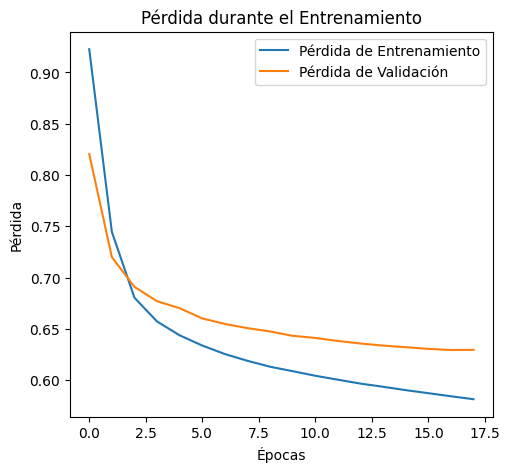

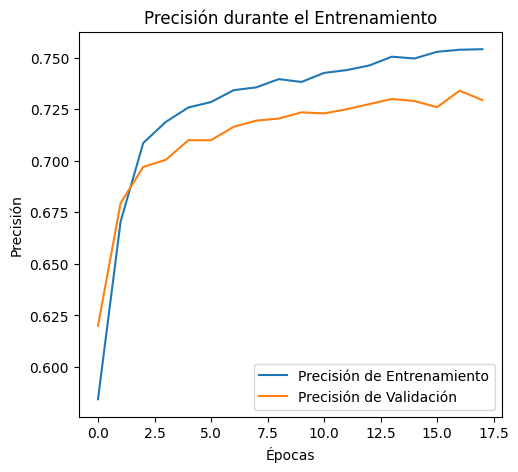

In [44]:
#Haz la grafica de la perdida y la precision durante el entrenamiento
import matplotlib.pyplot as plt
# Gráfica de pérdida
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Pérdida durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()
# Gráfica de precisión
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Precisión de Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de Validación')
plt.title('Precisión durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()

6. Prueba de red neuronal

In [45]:
# Ahora, probar el modelo con el conjunto de TEST para obtener la métrica final de desempeño
test_loss, test_accuracy = model_temp.evaluate(X_test_pca, y_test)
print(f"Desempeño en TEST - Pérdida: {test_loss:.4f}, Precisión: {test_accuracy:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7219 - loss: 0.6844
Desempeño en TEST - Pérdida: 0.6436, Precisión: 0.7300


7. Persistencia del modelo

In [46]:
# Conectar con el drive y guardar el modelo
model_temp.save('/content/drive/MyDrive/modelo_credit_score.keras')